In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [3]:
url = "https://api.dexpaprika.com/networks/solana/dexes/raydium/pools?order_by=created_at&sort=desc"
data = requests.get(url).json()
pools = pd.DataFrame(data.get("pools", []))
print(pools)
pools.to_csv("raydium_pools.csv", index=False)

                                              id   dex_id dex_name   chain  \
0   Cg22XgPipqMMw7Co9sc2X7RhCWRjoPUokydJMG9y731E  raydium  Raydium  solana   
1   7neh4kCyAtLgAZ5dJuTaBHVpCkXmNFrWxJaGXUdQmFCa  raydium  Raydium  solana   
2   888H8iR1yUQfgFhUVzmnpT2ZH1YkXDjuquXQCKZdFr9c  raydium  Raydium  solana   
3    JZg6epQ33dM7xBsVVPmujtngptBLPBHBYjGBshihfaq  raydium  Raydium  solana   
4   91MnYJJac3DYTCbnA2q4Wq4xQ5dCvpFqHRPEmm2vamhT  raydium  Raydium  solana   
..                                           ...      ...      ...     ...   
95  4SyGzqfrjkUEcAMe9QJGHsRgzb9kBaNmJfguctudpTsH  raydium  Raydium  solana   
96  7RSK9Tqa1hWiPq3son3PGvCcwKHnqUKGV4qs9LJtnizi  raydium  Raydium  solana   
97  DjoVdimoaa6SCcr8WTqU9EdZKKAWa5ytHvJT21h2vg49  raydium  Raydium  solana   
98  428nP1oq4kaNeUwCvrPUHb443MB9wriodq5WYHxGopK1  raydium  Raydium  solana   
99  2BsAHbXXykju3cKFkoewgvYHazcJSgE8RaAfhyM5xG76  raydium  Raydium  solana   

     volume_usd            created_at  created_at_block_number 

**Single Feature Linear Regression**

In [4]:
x_raw = np.array(pools['transactions'])
y_raw = np.array(pools['volume_usd'])

x_mean, x_std = np.mean(x_raw), np.std(x_raw)
y_mean, y_std = np.mean(y_raw), np.std(y_raw)

x_train = (x_raw - x_mean) / x_std
y_train = (y_raw - y_mean) / y_std

def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros([m])
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

def compute_cost_function(x, y, w, b):
    m = x.shape[0]
    total_cost = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        total_cost += (f_wb_i - y[i]) ** 2
    total_cost /= (2 * m)
    return total_cost  

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        dj_dw_i = (f_wb_i - y[i]) * x[i]
        dj_db_i = f_wb_i - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost_function(x, y, w, b))
    return w, b, J_history

w = 0.0
b = 0
alpha = 0.01
num_iters = 1000
w_final, b_final, J_history = gradient_descent(x_train, y_train, w, b, alpha, num_iters)

def predict_volume(transactions, w, b):
    x_scaled = (transactions - x_mean) / x_std
    y_scaled = w * x_scaled + b
    return y_scaled * y_std + y_mean

for i in range(10):
    actual_txns   = x_raw[i]
    actual_volume = y_raw[i]
    predicted     = predict_volume(actual_txns, w_final, b_final)
    error         = predicted - actual_volume

    print(f"{actual_txns:>14.0f}| ${actual_volume:>13,.2f}| ${predicted:>15,.2f}| ${error:>9,.2f}")

             8| $         2.63| $        -402.25| $  -404.87
             4| $         0.06| $        -574.66| $  -574.72
             2| $         0.10| $        -660.87| $  -660.96
            15| $        12.54| $        -100.53| $  -113.07
            37| $        12.94| $         847.74| $   834.79
            16| $       580.13| $         -57.43| $  -637.56
           347| $    11,585.98| $      14,209.63| $ 2,623.65
            23| $         9.14| $         244.30| $   235.16
           156| $       690.85| $       5,976.98| $ 5,286.13
            11| $        50.85| $        -272.94| $  -323.79


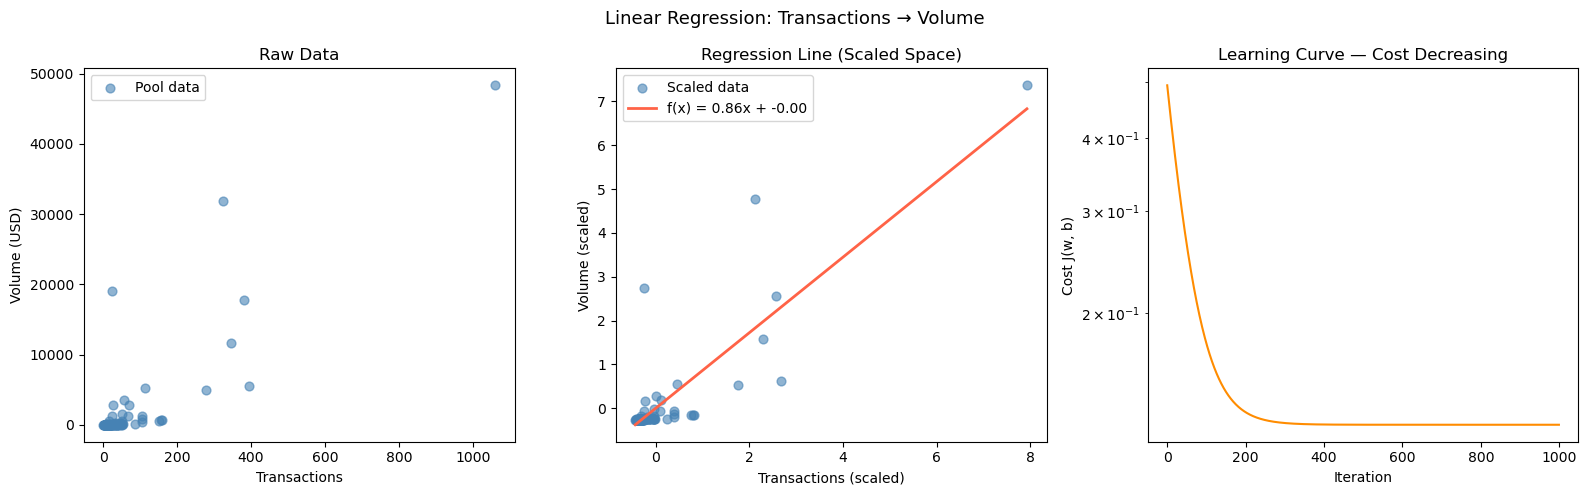

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Regression: Transactions → Volume", fontsize=13)

ax = axes[0]
ax.scatter(x_raw, y_raw, color='steelblue', alpha=0.6, s=40, label='Pool data')
ax.set_xlabel("Transactions")
ax.set_ylabel("Volume (USD)")
ax.set_title("Raw Data")
ax.legend()


ax = axes[1]
x_line = np.linspace(x_train.min(), x_train.max(), 100)
y_line = w_final * x_line + b_final
ax.scatter(x_train, y_train, color='steelblue', alpha=0.6, s=40, label='Scaled data')
ax.plot(x_line, y_line, color='tomato', linewidth=2, label=f'f(x) = {w_final:.2f}x + {b_final:.2f}')
ax.set_xlabel("Transactions (scaled)")
ax.set_ylabel("Volume (scaled)")
ax.set_title("Regression Line (Scaled Space)")
ax.legend()

ax = axes[2]
ax.plot(range(num_iters), J_history, color='darkorange', linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w, b)")
ax.set_title("Learning Curve — Cost Decreasing")
ax.set_yscale('log')

plt.tight_layout()
plt.show()

**For Multiples features**

In [6]:
def extract_token_info(tokens_str):
    SOL_ID = 'So11111111111111111111111111111111111111112'
    try:
        tokens = ast.literal_eval(tokens_str)
        for token in tokens:
            if token['id'] != SOL_ID:
                fdv       = token.get('fdv') or 0.0
                has_image = 1 if token.get('has_image') else 0
                return fdv, has_image
    except:
        pass
    return 0.0, 0 
pools[['meme_fdv', 'has_image']] = pools['tokens'].apply(lambda x: pd.Series(extract_token_info(x)))
            
pools = pools[(pools['transactions'] > 0) & (pools['volume_usd'] > 0)].reset_index(drop=True)
pools['last_price_change_usd_1h']  = pools['last_price_change_usd_1h'].fillna(0)
pools['last_price_change_usd_24h'] = pools['last_price_change_usd_24h'].fillna(0)

X_raw = np.column_stack([
    pools['transactions'].values,              
    pools['last_price_change_usd_1h'].values,  
    pools['last_price_change_usd_24h'].values, 
    pools['meme_fdv'].values,                  
    pools['has_image'].values                  
])

y_raw = pools['volume_usd'].values

m, n = X_raw.shape
print(f"X shape: {X_raw.shape}  →  {m} pools, {n} features")
print(f"y shape: {y_raw.shape}")
            

def z_score_normalize(X):
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)
    std[std == 0] = 1
    return (X - mean) / std, mean, std
X_train, X_mean, X_std = z_score_normalize(X_raw)
y_train, y_mean, y_std = z_score_normalize(y_raw.reshape(-1, 1))
y_train = y_train.flatten()

X shape: (99, 5)  →  99 pools, 5 features
y shape: (99,)


In [7]:
def compute_model_output_multi(X, w, b):
    m = X.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = np.dot(w, X[i]) + b
    return f_wb

def compute_cost_function_multi(X, y, w, b):
    m = X.shape[0]
    total_cost = 0
    for i in range(m):
        f_wb_i = np.dot(w, X[i]) + b
        total_cost += (f_wb_i - y[i]) ** 2
    total_cost /= (2 * m)
    return total_cost

def compute_gradient_multi(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        f_wb_i = np.dot(w, X[i]) + b
        error_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += error_i * X[i][j]
        dj_db += error_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

def gradient_descent_multi(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_multi(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost_function_multi(X, y, w, b))
    return w, b, J_history
w_init = np.zeros(X_train.shape[1])
b_init = 0
alpha = 0.01
num_iters = 1000
w_final, b_final, J_history = gradient_descent_multi(X_train, y_train, w_init, b_init, alpha, num_iters)

def predict_volume(X_raw_row, w, b):
    x_scaled = (X_raw_row - X_mean) / X_std  
    y_scaled  = np.dot(w, x_scaled) + b       
    return (y_scaled * y_std + y_mean).item()    

print("\nPredictions vs Actual (first 10 pools):")
print(f"{'Transactions':>14} | {'Actual Volume':>14} | {'Predicted Volume':>16} | {'Error':>10}")
print("-" * 75)

for i in range(10):
    actual_volume = y_raw[i]
    predicted     = predict_volume(X_raw[i], w_final, b_final)
    error         = predicted - actual_volume
    print(f"{X_raw[i][0]:>14.0f} | ${actual_volume:>13,.2f} | ${predicted:>15,.2f} | ${error:>9,.2f}")



Predictions vs Actual (first 10 pools):
  Transactions |  Actual Volume | Predicted Volume |      Error
---------------------------------------------------------------------------
             8 | $         2.63 | $        -371.78 | $  -374.41
             4 | $         0.06 | $        -541.69 | $  -541.75
             2 | $         0.10 | $        -624.94 | $  -625.04
            15 | $        12.54 | $         -66.71 | $   -79.26
            37 | $        12.94 | $         867.95 | $   855.01
            16 | $       580.13 | $         -26.32 | $  -606.45
           347 | $    11,585.98 | $      15,044.21 | $ 3,458.23
            23 | $         9.14 | $         267.52 | $   258.38
           156 | $       690.85 | $       5,915.99 | $ 5,225.14
            11 | $        50.85 | $        -409.64 | $  -460.49


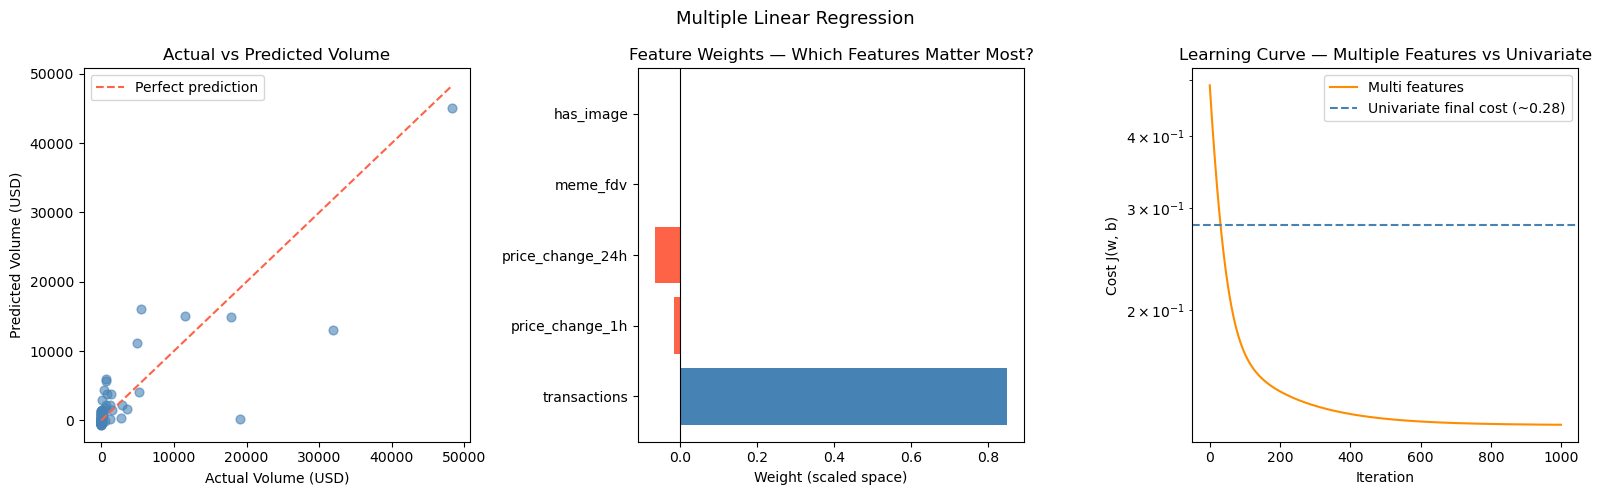

In [8]:
feature_names = ['transactions', 'price_change_1h', 'price_change_24h', 'meme_fdv', 'has_image']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Multiple Linear Regression", fontsize=13)

y_pred_all = compute_model_output_multi(X_train, w_final, b_final) * y_std + y_mean
ax = axes[0]
ax.scatter(y_raw, y_pred_all, color='steelblue', alpha=0.6, s=40)
ax.plot([y_raw.min(), y_raw.max()],
        [y_raw.min(), y_raw.max()],
        color='tomato', linewidth=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel("Actual Volume (USD)")
ax.set_ylabel("Predicted Volume (USD)")
ax.set_title("Actual vs Predicted Volume")
ax.legend()

ax = axes[1]
colors = ['steelblue' if w >= 0 else 'tomato' for w in w_final]
ax.barh(feature_names, w_final, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Weight (scaled space)")
ax.set_title("Feature Weights — Which Features Matter Most?")

ax = axes[2]
ax.plot(J_history, color='darkorange', linewidth=1.5, label='Multi features')
ax.axhline(y=0.28, color='steelblue', linewidth=1.5,
           linestyle='--', label='Univariate final cost (~0.28)')
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w, b)")
ax.set_title("Learning Curve — Multiple Features vs Univariate")
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

**Classification**

In [9]:
VOLUME_THRESHOLD = 500
TX_THRESHOLD     = 30

y = ((pools['volume_usd'] > VOLUME_THRESHOLD) & (pools['transactions'] > TX_THRESHOLD)).astype(int).values

print(f"Active pools (1): {y.sum()}")
print(f"Dead pools   (0): {(y == 0).sum()}")

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_model_output_logistic(X, w, b):
    return sigmoid(np.dot(X, w) + b)


def compute_cost_logistic(X, y, w, b):
    f = compute_model_output_logistic(X, w, b)
    f = np.clip(f, 1e-15, 1 - 1e-15) 
    return -np.mean(y * np.log(f) + (1 - y) * np.log(1 - f))

def compute_gradient_logistic(X, y, w, b):
    m      = X.shape[0]
    f      = compute_model_output_logistic(X, w, b)
    errors = f - y
    dj_dw  = np.dot(X.T , errors) / m
    dj_db  = np.sum(errors) / m
    return dj_dw, dj_db


def gradient_descent_logistic(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost_logistic(X, y, w, b))
        if i % 100 == 0:
            print(f"  Iter {i:4d} | Cost: {J_history[-1]:.6f}")
    return w, b, J_history


w_init    = np.zeros(n)
b_init    = 0.0
alpha     = 0.01
num_iters = 1000

w_final, b_final, J_history = gradient_descent_logistic(X_train, y, w_init, b_init, alpha, num_iters)


def predict(X_raw_row, w, b, threshold=0.5):
    x_scaled    = (X_raw_row - X_mean) / X_std
    probability = sigmoid(np.dot(w, x_scaled) + b)
    label       = 1 if probability >= threshold else 0
    return label, probability

probs    = compute_model_output_logistic(X_train, w_final, b_final)
y_pred   = (probs >= 0.5).astype(int)
accuracy = np.mean(y_pred == y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")

print(f"\n{'Transactions':>14} | {'Volume':>10} | {'Actual':>8} | {'Predicted':>10} | {'Probability':>12}")
print("-" * 65)
for i in range(10):
    label_pred, prob = predict(X_raw[i], w_final, b_final)
    correct = "✓" if label_pred == y[i] else "✗"
    print(f"{X_raw[i,0]:>14.0f} | ${pools['volume_usd'].iloc[i]:>9,.0f} | {y[i]:>8} | {label_pred:>10} | {prob:>11.4f}  {correct}")


Active pools (1): 17
Dead pools   (0): 82
  Iter    0 | Cost: 0.691329
  Iter  100 | Cost: 0.553878
  Iter  200 | Cost: 0.471746
  Iter  300 | Cost: 0.418502
  Iter  400 | Cost: 0.381936
  Iter  500 | Cost: 0.355630
  Iter  600 | Cost: 0.335951
  Iter  700 | Cost: 0.320733
  Iter  800 | Cost: 0.308629
  Iter  900 | Cost: 0.298765

Accuracy: 89.9%

  Transactions |     Volume |   Actual |  Predicted |  Probability
-----------------------------------------------------------------
             8 | $        3 |        0 |          0 |      0.1415  ✓
             4 | $        0 |        0 |          0 |      0.1372  ✓
             2 | $        0 |        0 |          0 |      0.1355  ✓
            15 | $       13 |        0 |          0 |      0.1516  ✓
            37 | $       13 |        0 |          0 |      0.1791  ✓
            16 | $      580 |        0 |          0 |      0.1521  ✓
           347 | $   11,586 |        1 |          1 |      0.9699  ✓
            23 | $        9 |     

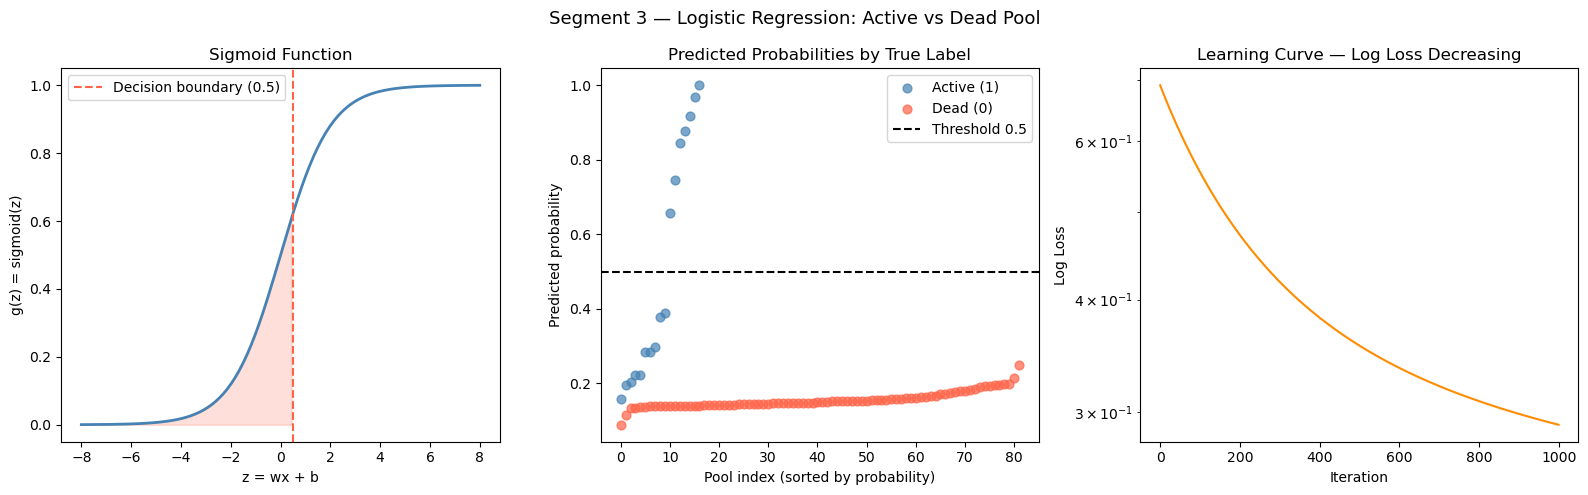

In [11]:
feature_names = ['transactions', 'price_change_1h', 'price_change_24h', 'meme_fdv', 'has_image']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Segment 3 — Logistic Regression: Active vs Dead Pool", fontsize=13)

# Plot 1: Sigmoid curve
ax = axes[0]
z_vals = np.linspace(-8, 8, 200)
ax.plot(z_vals, sigmoid(z_vals), color='steelblue', linewidth=2)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
ax.fill_between(z_vals, 0, sigmoid(z_vals), where=(z_vals < 0.5), color='tomato', alpha=0.2)
ax.set_xlabel("z = wx + b")
ax.set_ylabel("g(z) = sigmoid(z)")
ax.set_title("Sigmoid Function")
ax.legend()

# Plot 2: Predicted probabilities by true label
ax = axes[1]
ax.scatter(range(len(probs[y == 1])), sorted(probs[y == 1]),
           color='steelblue', s=40, alpha=0.7, label='Active (1)')
ax.scatter(range(len(probs[y == 0])), sorted(probs[y == 0]),
           color='tomato', s=40, alpha=0.7, label='Dead (0)')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_xlabel("Pool index (sorted by probability)")
ax.set_ylabel("Predicted probability")
ax.set_title("Predicted Probabilities by True Label")
ax.legend()

# Plot 3: Learning curve
ax = axes[2]
ax.plot(J_history, color='darkorange', linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Log Loss")
ax.set_title("Learning Curve — Log Loss Decreasing")
ax.set_yscale('log')

plt.tight_layout()
plt.show()

**Using SciKit-learn's Logistic Regression**

Training pools: 79
Testing pools:  20
Test Accuracy:  90.0%
Difference:     2.4%
✓  No significant overfitting detected
Sklearn Accuracy: 92.4%
Sklearn Train Accuracy: 92.4%


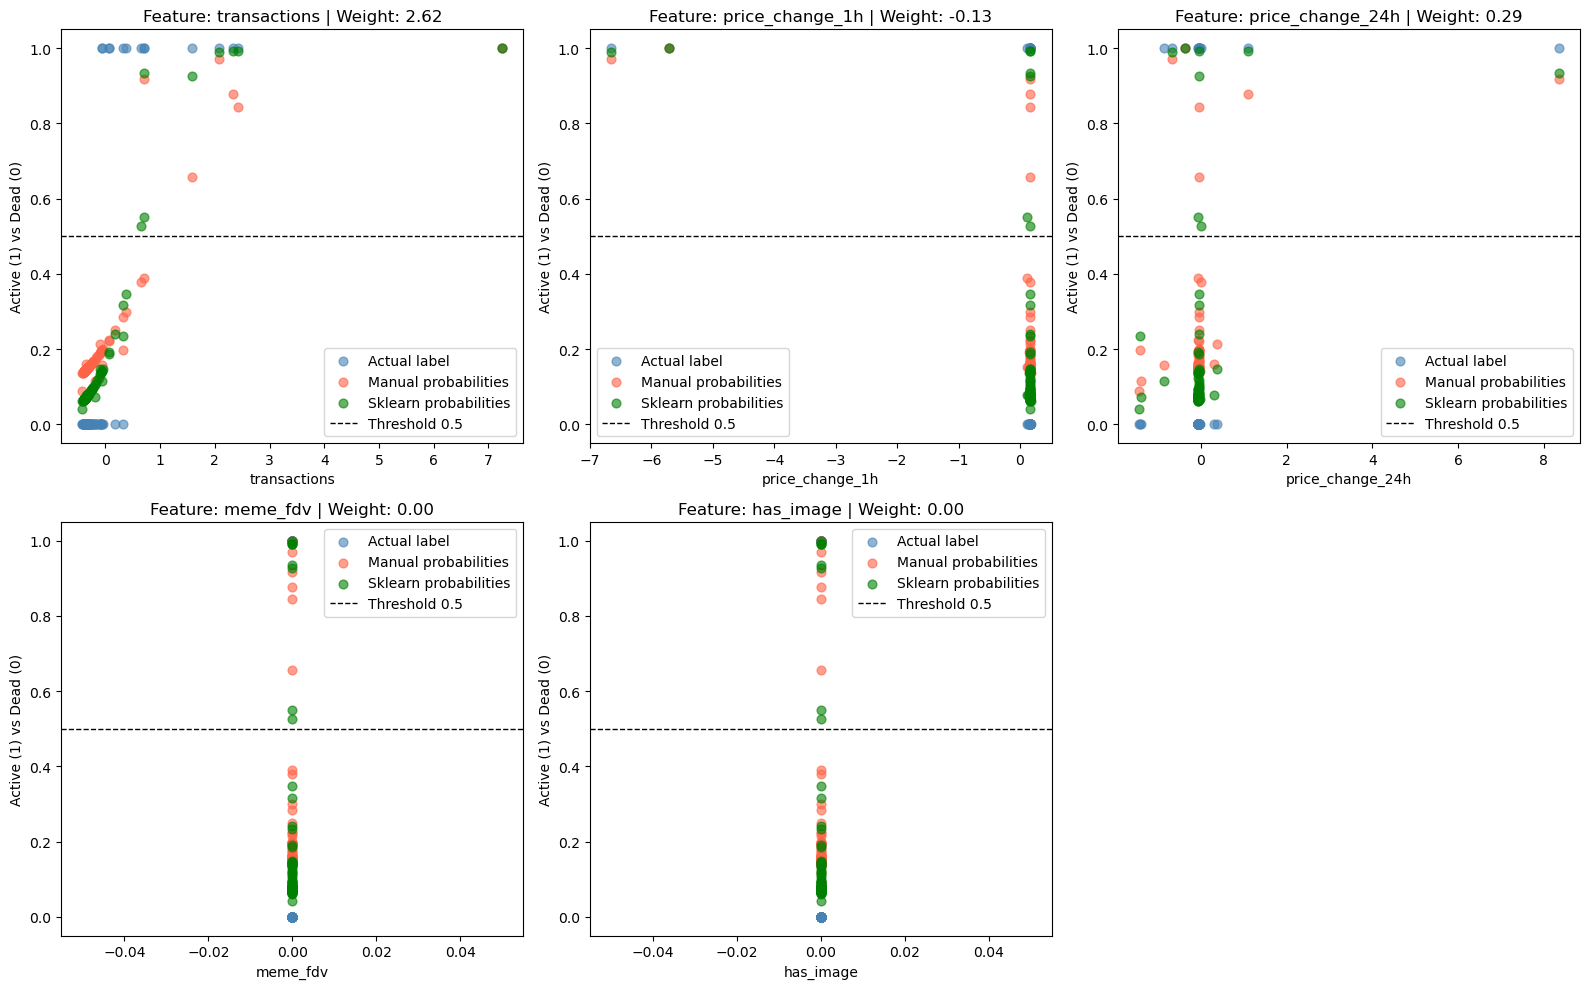

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_split, y_test_split = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print(f"Training pools: {len(X_train_raw)}")
print(f"Testing pools:  {len(X_test_raw)}")

scaler      = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw) 
X_test_scaled  = scaler.transform(X_test_raw)

model = LogisticRegression(max_iter=1000, tol=1e-3)
model.fit(X_train_scaled, y_train_split)

train_accuracy = np.mean(model.predict(X_train_scaled) == y_train_split) * 100
test_accuracy  = np.mean(model.predict(X_test_scaled)  == y_test_split)  * 100

print(f"Test Accuracy:  {test_accuracy:.1f}%")
print(f"Difference:     {train_accuracy - test_accuracy:.1f}%")

if train_accuracy - test_accuracy > 10:
    print("⚠️  Possible overfitting — gap is large")
else:
    print("✓  No significant overfitting detected")
print(f"Sklearn Accuracy: {accuracy:.1f}%")

X_train_raw_manual = (X_train_raw - X_mean) / X_std
probs_train        = compute_model_output_logistic(X_train_raw_manual, w_final, b_final)
sklearn_probs_train = model.predict_proba(X_train_scaled)[:, 1]

accuracy = np.mean(model.predict(X_train_scaled) == y_train_split) * 100
w_norm   = model.coef_[0]

print(f"Sklearn Train Accuracy: {accuracy:.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(5):
    axes[i].scatter(X_train_scaled[:, i], y_train_split,       color='steelblue', alpha=0.6, s=40, label='Actual label')
    axes[i].scatter(X_train_scaled[:, i], probs_train,         color='tomato',    alpha=0.6, s=40, label='Manual probabilities')
    axes[i].scatter(X_train_scaled[:, i], sklearn_probs_train, color='green',     alpha=0.6, s=40, label='Sklearn probabilities')
    axes[i].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel("Active (1) vs Dead (0)")
    axes[i].set_title(f"Feature: {feature_names[i]} | Weight: {w_norm[i]:.2f}")
    axes[i].legend()

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()